In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from unidecode import unidecode
import seaborn as sns
import matplotlib.pyplot as plt

In [242]:
df=pd.read_csv('ChocoCrunchAnalytics.csv',encoding='utf_8',index_col=0)
df.head(5)

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,Sidi Ali,6111035000430,Sidi Ali,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.0,0.00000,0.000000,NaN,1.0,0.0
1,Jaouda,6111242100992,Perly,97.0,406.0,9.4,NaN,3.0,NaN,8.0,NaN,NaN,NaN,3.0,NaN,0.0
2,sidi ali,6111035002175,Sidi Ali,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,NaN,0.0,0.0
3,"Les Eaux Minérales d'oulmès,Sidi Ali",6111035000058,Eau minérale naturelle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,1.0,0.0,0.0
4,AQUAFINA,6111252421568,اكوافينا,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,NaN,0.0,0.0


In [243]:
df.duplicated().sum()

np.int64(0)

In [244]:
df.shape

(11997, 16)

In [245]:
df.isnull().sum()

brands                                                    652
code                                                        0
product_name                                              546
energy-kcal_value                                         764
energy-kj_value                                          5571
carbohydrates_value                                       765
sugars_value                                              979
fat_value                                                 737
saturated-fat_value                                      1049
proteins_value                                            747
fiber_value                                              3822
salt_value                                               1076
sodium_value                                             1076
nova-group                                               1267
nutrition-score-fr                                       1685
fruits-vegetables-nuts-estimate-from-ingredients_100g     725
dtype: i

In [246]:
fribrenull=(3822/11997)*100
print(f'fiber_value column has {fribrenull:.2f}% null vaues')


fiber_value column has 31.86% null vaues


In [247]:
#removing fiber_value column
df=df.drop('fiber_value',axis=1)

In [248]:
#dropping null values in brands and product_name
df = df.dropna(subset=["brands","product_name"],how='all')
df.shape

(11749, 15)

In [249]:
df.isnull().sum()

brands                                                    404
code                                                        0
product_name                                              298
energy-kcal_value                                         561
energy-kj_value                                          5340
carbohydrates_value                                       558
sugars_value                                              766
fat_value                                                 534
saturated-fat_value                                       837
proteins_value                                            542
salt_value                                                868
sodium_value                                              868
nova-group                                               1072
nutrition-score-fr                                       1468
fruits-vegetables-nuts-estimate-from-ingredients_100g     541
dtype: int64

In [250]:
datalost=100-((11749/11997)*100)
print(f'{datalost:.2f}% of data lost after removing the missing values in brands')

2.07% of data lost after removing the missing values in brands


In [251]:
nutrients_columns=['energy_kcal_value',
       'energy_kj_value', 'carbohydrates_value', 'sugars_value', 'fat_value',
       'saturated_fat_value', 'proteins_value', 'salt_value', 'sodium_value',
        'nutrition_score_fr',
       'fruits_vegetables_nuts_estimate_from_ingredients_100g']

In [252]:
df.columns=df.columns.str.replace('-','_')

In [253]:
df['brands']=df['brands'].str.replace(r'[^A-Za-z0-9\s]', '', regex=True)
df['product_name']=df['product_name'].str.replace(r'[^A-Za-z0-9\s]', '', regex=True)
df.head()

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g
0,Sidi Ali,6111035000430,Sidi Ali,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.00000,0.000000,NaN,1.0,0.0
1,Jaouda,6111242100992,Perly,97.0,406.0,9.4,NaN,3.0,NaN,8.0,NaN,NaN,3.0,NaN,0.0
2,sidi ali,6111035002175,Sidi Ali,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,NaN,0.0,0.0
3,Les Eaux Minrales doulmsSidi Ali,6111035000058,Eau minrale naturelle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,1.0,0.0,0.0
4,AQUAFINA,6111252421568,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,NaN,0.0,0.0


In [254]:
df['brands'] = df['brands'].str.lower()
df['product_name'] = df['product_name'].str.lower()


In [255]:
df['product_name']=df['product_name'].astype(str).apply(unidecode)
df['brands']=df['brands'].astype(str).apply(unidecode)
df.head()

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g
0,sidi ali,6111035000430,sidi ali,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.00000,0.000000,NaN,1.0,0.0
1,jaouda,6111242100992,perly,97.0,406.0,9.4,NaN,3.0,NaN,8.0,NaN,NaN,3.0,NaN,0.0
2,sidi ali,6111035002175,sidi ali,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,NaN,0.0,0.0
3,les eaux minrales doulmssidi ali,6111035000058,eau minrale naturelle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,1.0,0.0,0.0
4,aquafina,6111252421568,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,NaN,0.0,0.0


#### Reducing NULL values in energy_kcal_value and energy_kj_value columns

In [256]:
mask = df['energy_kcal_value'].isna() & df['energy_kj_value'].notna()
df.loc[mask, 'energy_kcal_value'] = df.loc[mask, 'energy_kj_value'] / 4.184
mask = df['energy_kj_value'].isna() & df['energy_kcal_value'].notna()
df.loc[mask, 'energy_kj_value'] = df.loc[mask, 'energy_kcal_value'] * 4.184
df.isnull().sum()

brands                                                      0
code                                                        0
product_name                                                0
energy_kcal_value                                         510
energy_kj_value                                           510
carbohydrates_value                                       558
sugars_value                                              766
fat_value                                                 534
saturated_fat_value                                       837
proteins_value                                            542
salt_value                                                868
sodium_value                                              868
nova_group                                               1072
nutrition_score_fr                                       1468
fruits_vegetables_nuts_estimate_from_ingredients_100g     541
dtype: int64

In [257]:
df.dtypes

brands                                                    object
code                                                       int64
product_name                                              object
energy_kcal_value                                        float64
energy_kj_value                                          float64
carbohydrates_value                                      float64
sugars_value                                             float64
fat_value                                                float64
saturated_fat_value                                      float64
proteins_value                                           float64
salt_value                                               float64
sodium_value                                             float64
nova_group                                               float64
nutrition_score_fr                                       float64
fruits_vegetables_nuts_estimate_from_ingredients_100g    float64
dtype: object

In [258]:
df['nova_group'].value_counts().sort_values(ascending=False)

nova_group
4.0    6274
3.0    2621
1.0    1285
2.0     497
Name: count, dtype: int64

In [259]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

# Count outliers for each nutrient column
outlier_counts = {}
for col in nutrients_columns:
    outliers = detect_outliers_iqr(df, col)
    outlier_counts[col] = len(outliers)
    

# Convert to DataFrame for better view
outlier_summary = pd.DataFrame(list(outlier_counts.items()), columns=['Column', 'Outlier_Count'])

outlier_summary.sort_values(by='Outlier_Count', ascending=False).reset_index(drop=True)



,Column,Outlier_Count
0,fruits_vegetables_nuts_estimate_from_ingredien...,1706
1,sugars_value,1269
2,saturated_fat_value,1195
3,fat_value,698
4,sodium_value,687
5,salt_value,687
6,proteins_value,672
7,nutrition_score_fr,9
8,carbohydrates_value,6
9,energy_kcal_value,4


In [260]:
detect_outliers_iqr(df, 'energy_kj_value')

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g
221,sunny via,3088543506255,sirop dagave,1600.0,6694.40,402.5,395.0,2.5,0.0,2.5,0.000,0.00,1.0,20.0,0.0
11915,jiffy,72486002205,corn muffin mix,990.0,4142.16,168.0,45.0,30.0,12.0,12.0,5.175,2.07,4.0,7.0,0.0


In [261]:
detect_outliers_iqr(df, 'energy_kcal_value')

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g
221,sunny via,3088543506255,sirop dagave,1600.000000,6694.40,402.5,395.0,2.5,0.0,2.5,0.000,0.00,1.0,20.0,0.0
2688,gastro mixte,6111259090132,pizzarella premium,5280.000000,1.00,63.0,0.0,40.0,52.0,8.0,20.000,8.00,4.0,27.0,0.0
5349,hacendado,8480000054647,semillas de cha,45793.499044,1916.00,3260.0,40.0,3400.0,400.0,3000.0,0.000,0.00,1.0,17.0,0.0
11915,jiffy,72486002205,corn muffin mix,990.000000,4142.16,168.0,45.0,30.0,12.0,12.0,5.175,2.07,4.0,7.0,0.0


In [262]:
Q1 = df['energy_kcal_value'].quantile(0.25)
Q3 = df['energy_kcal_value'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['energy_kcal_value'] = df['energy_kcal_value'].clip(lower, upper)

In [263]:
detect_outliers_iqr(df, 'energy_kj_value')

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g
221,sunny via,3088543506255,sirop dagave,947.5,6694.40,402.5,395.0,2.5,0.0,2.5,0.000,0.00,1.0,20.0,0.0
11915,jiffy,72486002205,corn muffin mix,947.5,4142.16,168.0,45.0,30.0,12.0,12.0,5.175,2.07,4.0,7.0,0.0


In [264]:
Q1 = df['energy_kj_value'].quantile(0.25)
Q3 = df['energy_kj_value'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['energy_kj_value'] = df['energy_kj_value'].clip(lower, upper)

In [265]:
detect_outliers_iqr(df, 'carbohydrates_value')

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g
221,sunny via,3088543506255,sirop dagave,947.5,3963.99431,402.5,395.0,2.5,0.0,2.5,0.000,0.000,1.0,20.0,0.000000
2430,pipas de la casa,3400938267266,nan,888.0,255.00000,8989.0,895.0,554.0,595.0,597.0,898.000,359.200,3.0,50.0,0.000000
2979,bisto,5000354919534,gravy granules,411.0,1728.00000,649.0,18.0,15.8,11.0,1.5,8.450,3.380,4.0,NaN,0.028568
5349,hacendado,8480000054647,semillas de cha,947.5,1916.00000,3260.0,40.0,3400.0,400.0,3000.0,0.000,0.000,1.0,17.0,0.000000
8643,golden sun,20364625,reis basmati reis,706.0,2953.90400,156.0,0.4,1.0,0.2,16.4,0.040,0.016,1.0,-1.0,0.000000
11915,jiffy,72486002205,corn muffin mix,947.5,3963.99431,168.0,45.0,30.0,12.0,12.0,5.175,2.070,4.0,7.0,0.000000


In [266]:
Q1 = df['carbohydrates_value'].quantile(0.25)
Q3 = df['carbohydrates_value'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(upper,lower)

130.6 -71.0


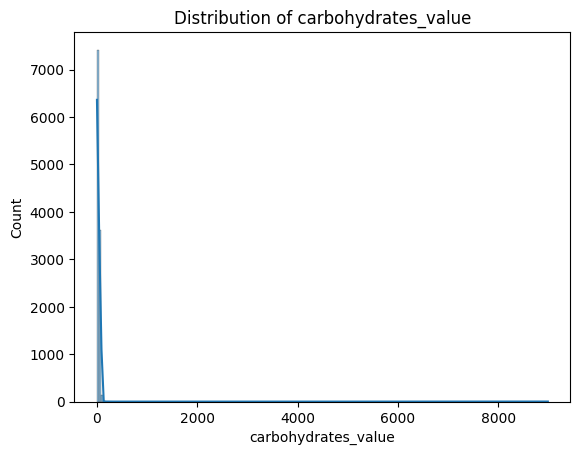

In [267]:
sns.histplot(df['carbohydrates_value'], kde=True)
plt.title(f'Distribution of carbohydrates_value')
plt.show()

In [268]:
df['carbohydrates_value'] = df['carbohydrates_value'].clip(lower, upper)

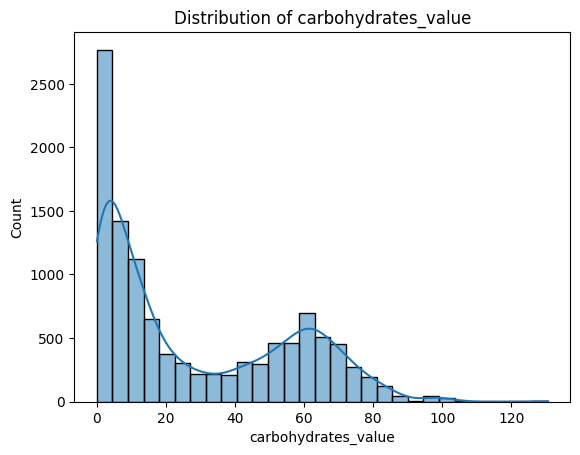

In [269]:
sns.histplot(df['carbohydrates_value'], kde=True)
plt.title(f'Distribution of carbohydrates_value')
plt.show()

In [270]:
detect_outliers_iqr(df, 'nutrition_score_fr')

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g
165,aperitivos company,6111252860077,trios,534.0,2234.256,54.0,54.00,32.1,32.10,5.20,2.00,0.800,4.0,40.0,0.000000
891,nan,6111260680452,marhaba,537.0,2246.808,55.3,55.30,32.7,32.70,5.60,5.00,2.000,4.0,51.0,8.000000
1550,aiguebelle,6111017046548,aiguebelle,535.0,2238.440,47.0,44.00,36.0,22.00,5.20,11.00,4.400,NaN,48.0,NaN
2430,pipas de la casa,3400938267266,nan,888.0,255.000,130.6,895.00,554.0,595.00,597.00,898.00,359.200,3.0,50.0,0.000000
3538,benco,3034470003114,benco,377.0,1598.000,80.0,78.00,2.3,1.40,4.80,0.22,0.088,4.0,39.0,0.000000
3614,president,3228021000084,meersalz butter,727.0,3041.768,1.0,1.00,80.0,55.00,0.70,6.25,2.500,2.0,40.0,0.000000
5609,excelo,6111242531086,sandwichs choc,375.0,1569.000,70.2,51.75,8.8,4.24,3.81,11.00,4.400,4.0,43.0,0.000000
10330,priccadeli,6291003084881,brio,501.0,2099.000,16.7,44.50,24.9,16.60,24.90,15.00,6.000,NaN,49.0,0.000000
10738,bisto,5000354923722,bisto graby granules,411.0,1719.624,64.9,18.00,15.8,11.00,1.50,8.31,3.324,4.0,40.0,0.022536


In [271]:
df = df[(df['nutrition_score_fr'] <= 40.0) | df['nutrition_score_fr'].isna()]

In [272]:
df.shape

(11744, 15)

In [273]:
df.isnull().sum()

brands                                                      0
code                                                        0
product_name                                                0
energy_kcal_value                                         510
energy_kj_value                                           510
carbohydrates_value                                       558
sugars_value                                              766
fat_value                                                 534
saturated_fat_value                                       837
proteins_value                                            542
salt_value                                                868
sodium_value                                              868
nova_group                                               1070
nutrition_score_fr                                       1468
fruits_vegetables_nuts_estimate_from_ingredients_100g     540
dtype: int64

In [274]:
def fill_energy(df,t):
    # Step 1: median by (brands, product_name)
    prod_median = df.groupby(['brands','product_name'])[t].transform('median')
    
    # Step 2: median by brand only
    brand_median = df.groupby('brands')[t].transform('median')
    pro_median = df.groupby('product_name')[t].transform('median')
    
    # Step 3: fill in order: product-level median first, then brand-level
    df[t] = df[t].fillna(prod_median).fillna(brand_median).fillna(pro_median)
    
    return df

#df = fill_energy(df,'nutrition-score-fr')

for i in nutrients_columns:
    df = fill_energy(df,i)

In [275]:
df.isnull().sum()

brands                                                      0
code                                                        0
product_name                                                0
energy_kcal_value                                          97
energy_kj_value                                            97
carbohydrates_value                                       108
sugars_value                                              158
fat_value                                                 104
saturated_fat_value                                       173
proteins_value                                            107
salt_value                                                149
sodium_value                                              149
nova_group                                               1070
nutrition_score_fr                                        364
fruits_vegetables_nuts_estimate_from_ingredients_100g      50
dtype: int64

In [276]:
for col in nutrients_columns:
    df[col] = df.groupby('brands')[col].transform(lambda x: x.fillna(x.mean()))


In [277]:
df.isnull().sum()

brands                                                      0
code                                                        0
product_name                                                0
energy_kcal_value                                          94
energy_kj_value                                            94
carbohydrates_value                                       105
sugars_value                                              152
fat_value                                                 101
saturated_fat_value                                       164
proteins_value                                            104
salt_value                                                143
sodium_value                                              143
nova_group                                               1070
nutrition_score_fr                                        333
fruits_vegetables_nuts_estimate_from_ingredients_100g      49
dtype: int64

In [278]:
for col in nutrients_columns:
    # Only fill within rows where product_name is not null
    mask = df['product_name'].notna()
    df.loc[mask, col] = (
        df[mask]
        .groupby('product_name')[col]
        .transform(lambda x: x.fillna(x.mean()))
    )

df.isnull().sum()


brands                                                      0
code                                                        0
product_name                                                0
energy_kcal_value                                          93
energy_kj_value                                            93
carbohydrates_value                                       103
sugars_value                                              149
fat_value                                                  98
saturated_fat_value                                       161
proteins_value                                            102
salt_value                                                137
sodium_value                                              137
nova_group                                               1070
nutrition_score_fr                                        317
fruits_vegetables_nuts_estimate_from_ingredients_100g      49
dtype: int64

In [279]:
df['nova_group'].value_counts()

nova_group
4.0    6272
3.0    2620
1.0    1285
2.0     497
Name: count, dtype: int64

In [280]:
df['nova_group'].value_counts()

nova_group
4.0    6272
3.0    2620
1.0    1285
2.0     497
Name: count, dtype: int64

In [281]:
import numpy as np
import pandas as pd

def _first_mode_or_nan(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

def fill_energy(df, t):
    # sanity checks
    if t not in df.columns:
        raise KeyError(f"column '{t}' not in dataframe")
    for g in ['brands', 'product_name']:
        if g not in df.columns:
            raise KeyError(f"grouping column '{g}' not in dataframe")

    # product-level mode (brands + product_name)
    prod_mode = df.groupby(['brands', 'product_name'])[t].transform(
        lambda x: _first_mode_or_nan(x)
    )

    # brand-level mode
    brand_mode = df.groupby('brands')[t].transform(
        lambda x: _first_mode_or_nan(x)
    )

    # product_name-level mode
    prodname_mode = df.groupby('product_name')[t].transform(
        lambda x: _first_mode_or_nan(x)
    )

    # fill in order: product-level, then brand-level, then product_name-level
    df[t] = df[t].fillna(prod_mode).fillna(brand_mode).fillna(prodname_mode)

    # optional: keep original dtype if numeric (after fill NaNs may make it float)
    try:
        if pd.api.types.is_integer_dtype(df[t].dtype):
            df[t] = df[t].astype(pd.Int64Dtype())  # nullable integer
    except Exception:
        pass

    return df


In [282]:
df = fill_energy(df, 'nova_group')


In [283]:
df['nova_group'].value_counts()

nova_group
4.0    6932
3.0    2717
1.0    1401
2.0     530
Name: count, dtype: int64

In [284]:
df.isnull().sum()

brands                                                     0
code                                                       0
product_name                                               0
energy_kcal_value                                         93
energy_kj_value                                           93
carbohydrates_value                                      103
sugars_value                                             149
fat_value                                                 98
saturated_fat_value                                      161
proteins_value                                           102
salt_value                                               137
sodium_value                                             137
nova_group                                               164
nutrition_score_fr                                       317
fruits_vegetables_nuts_estimate_from_ingredients_100g     49
dtype: int64

In [285]:
df_null = df[df.isnull().any(axis=1)]
df_null


,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g
11,ain atlas,6111035502828,eau minral naturelle,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.00000,0.0000,NaN,0.0,0.000000
22,les eaux minrales doulms sa,6111035003035,oulmes natural carbonated water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.78375,0.3135,NaN,0.0,0.000000
30,eau minrale naturelle des montagnes datlas,6111035001659,ain atlas,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.00000,0.0000,NaN,0.0,0.000000
34,eau minrale naturelle,6111035001635,ain atlas,0.0,0.000,0.0,0.0,0.0,0.0,0.0,120.00000,48.0000,NaN,0.0,0.000000
49,cosumar,6111029000118,cosumar sucre en lingot pour le th 1 kg,400.0,1700.000,100.0,100.0,0.0,0.0,0.0,0.00000,0.0000,NaN,20.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11961,lesserevil,180999001001,popcorn himalayan pink salt,190.0,794.960,28.0,NaN,7.0,5.0,4.0,0.87500,0.3500,3.0,NaN,0.000000
11962,reds,5039303002386,reds kansas city bbq sauce mild,143.0,598.312,32.8,29.1,0.5,0.1,1.0,NaN,NaN,4.0,NaN,12.164286
11971,larbre vert,3450601046254,3450601046254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11972,by sainsburys wholesome,475730,wholemeal bread flour,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-4.0,0.000000


In [289]:
df = df.drop(index=df_null.index)
totdatadrop=((253+492)/11997)*100
print(f"{totdatadrop:.1f}% of total data were not reliable so has been dropped")

6.2% of total data were not reliable so has been dropped


In [290]:
df

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g
0,sidi ali,6111035000430,sidi ali,0.0,20.000,42.0,14.0,0.0,0.00,0.0,0.00000,0.000000,1.0,1.0,0.000000
1,jaouda,6111242100992,perly,97.0,406.000,9.4,7.5,3.0,1.15,8.0,0.00000,0.000000,3.0,4.0,0.000000
2,sidi ali,6111035002175,sidi ali,0.0,20.000,42.0,14.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.000000
3,les eaux minrales doulmssidi ali,6111035000058,eau minrale naturelle,0.0,0.000,0.0,0.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.000000
4,aquafina,6111252421568,,0.0,0.000,0.0,0.0,0.0,0.00,0.0,0.00508,0.002032,1.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11992,nairns,612322001612,nairns dark chocolate chip oat biscuits,454.0,1902.000,63.8,19.0,16.9,7.70,8.1,0.78000,0.312000,4.0,16.0,0.000000
11993,swizzels,5010478014510,drumstick squashies,356.0,1489.504,84.0,63.0,0.2,0.00,3.4,0.07000,0.028000,4.0,19.0,0.351562
11994,twinings sainsburys,70177067779,twinings tea,2.0,8.368,0.0,0.0,0.0,0.00,0.0,0.00000,0.000000,1.0,-6.0,100.000000
11995,nan,88882222,eau de coco,12.0,50.208,3.2,3.2,0.0,0.00,0.0,0.00300,0.001200,4.0,3.0,0.000000


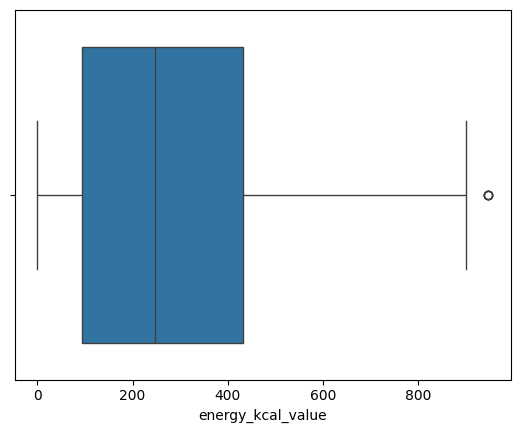

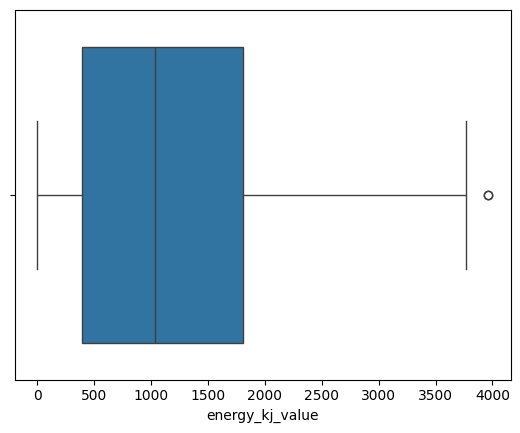

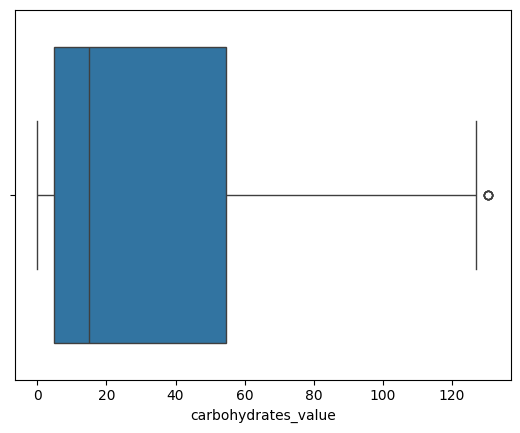

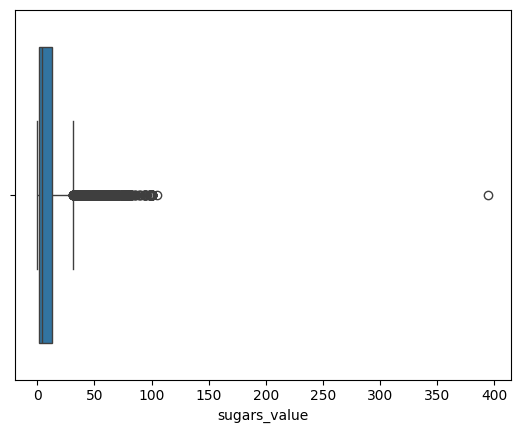

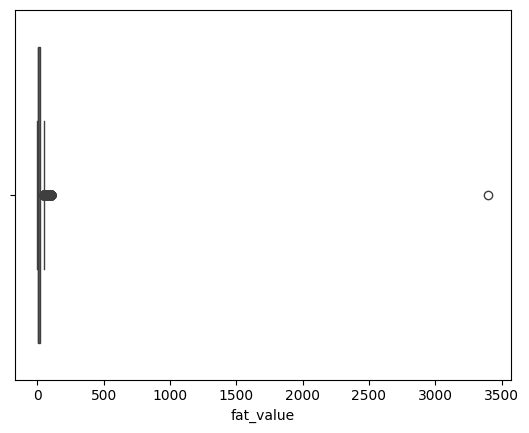

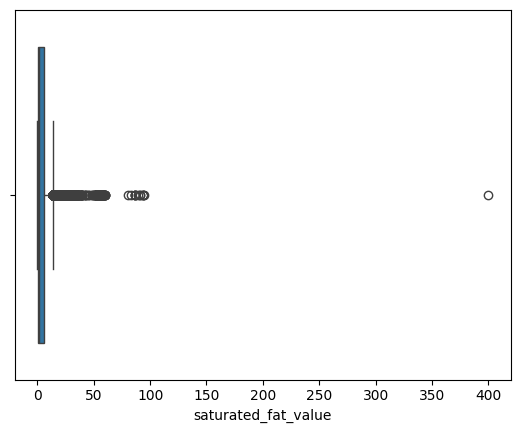

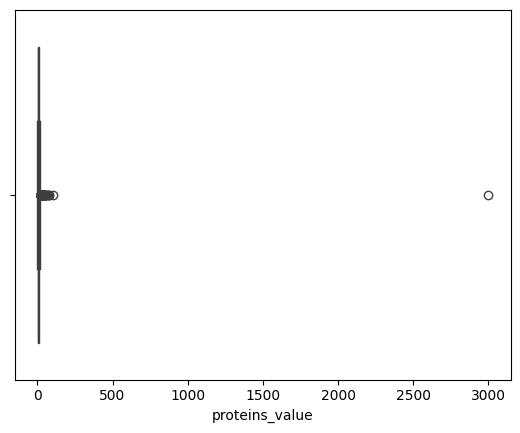

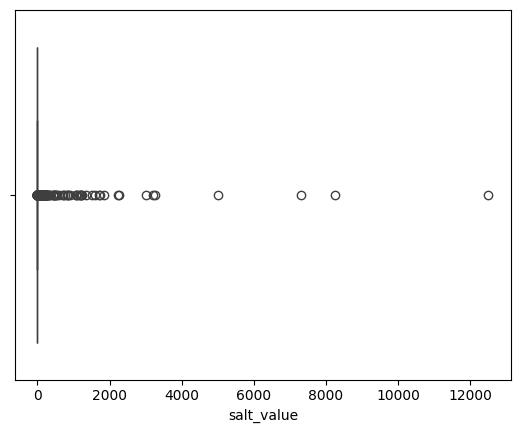

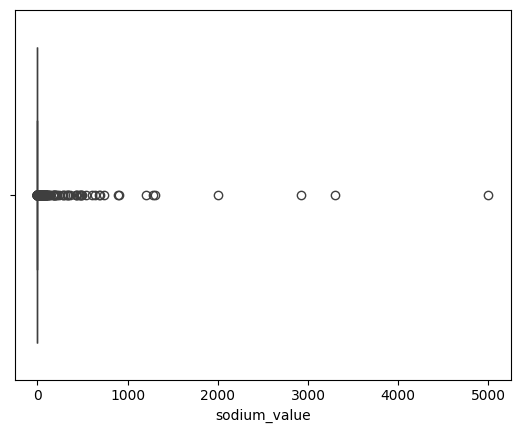

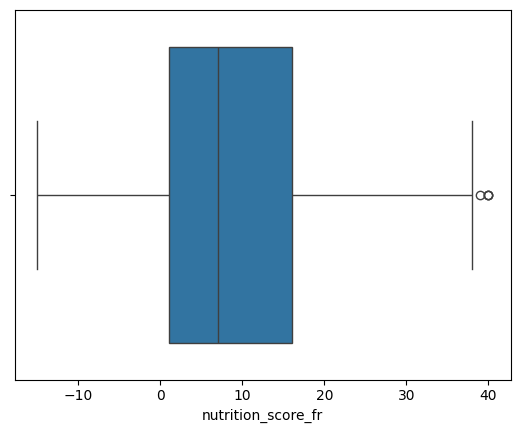

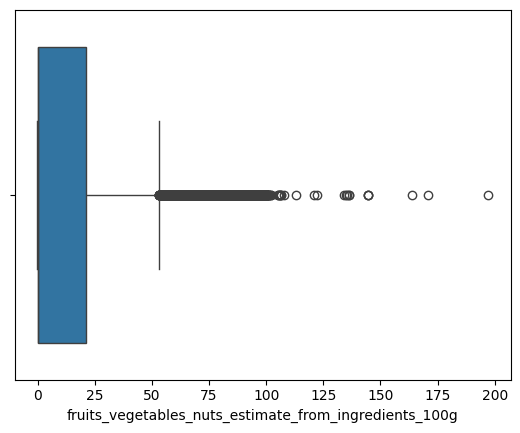

In [291]:
for i in nutrients_columns:

    sns.boxplot(x=df[i])
    plt.show()


In [292]:
df.columns

Index(['brands', 'code', 'product_name', 'energy_kcal_value',
       'energy_kj_value', 'carbohydrates_value', 'sugars_value', 'fat_value',
       'saturated_fat_value', 'proteins_value', 'salt_value', 'sodium_value',
       'nova_group', 'nutrition_score_fr',
       'fruits_vegetables_nuts_estimate_from_ingredients_100g'],
      dtype='object')

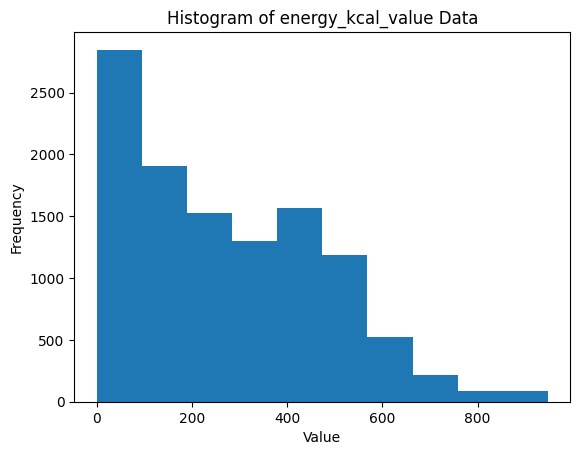

In [296]:
plt.hist(df['energy_kcal_value'],10)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of energy_kcal_value Data")
plt.show()

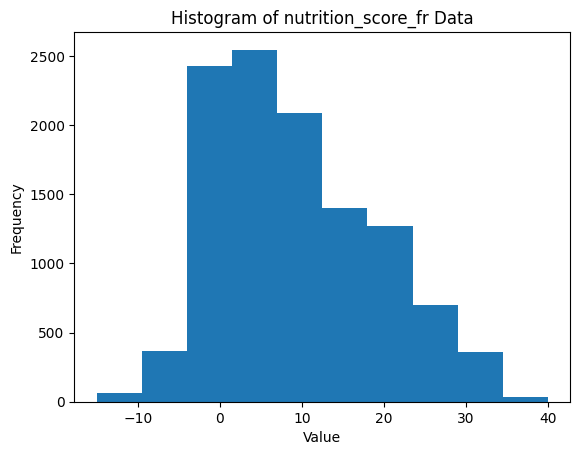

In [297]:
plt.hist(df['nutrition_score_fr'],
         10)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of nutrition_score_fr Data")
plt.show()

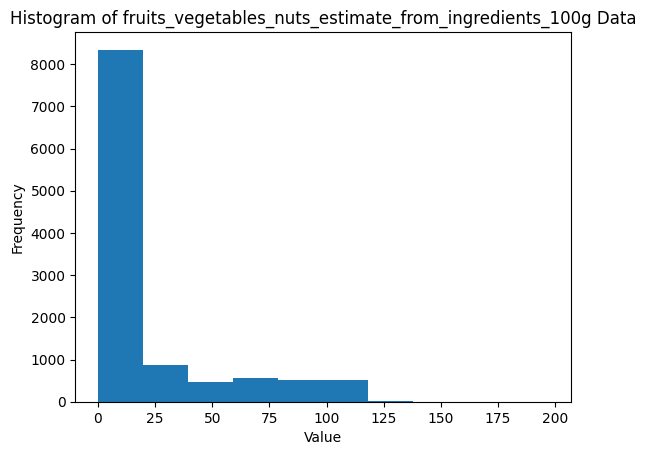

In [298]:
plt.hist(df['fruits_vegetables_nuts_estimate_from_ingredients_100g'],
         10)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of fruits_vegetables_nuts_estimate_from_ingredients_100g Data")
plt.show()

In [303]:
df.to_csv('cleanenddata1.csv')